## ThinkDSP

This notebook contains code examples from Chapter 6: Discrete Cosine Transform

Copyright 2015 Allen Downey

License: [Creative Commons Attribution 4.0 International](http://creativecommons.org/licenses/by/4.0/)

In [1]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)

download("https://github.com/AllenDowney/ThinkDSP/raw/master/thinkdsp/thinkdsp.py")


In [2]:
import numpy as np
PI2 = np.pi * 2

### Synthesis

The simplest way to synthesize a mixture of sinusoids is to add up sinusoid signals and evaluate the sum.

In [2]:
from thinkdsp import CosSignal, SumSignal

def synthesize1(amps, fs, ts):
    components = [CosSignal(freq, amp)
                  for amp, freq in zip(amps, fs)]
    signal = SumSignal(*components)

    ys = signal.evaluate(ts)
    return ys

Here's an example that's a mixture of 4 components.

In [5]:
from thinkdsp import Wave
import numpy as np

amps = np.array([0.6, 0.25, 0.1, 0.05])
fs = [100, 200, 300, 400]
framerate = 11025

ts = np.linspace(0, 1, framerate, endpoint=False)
ys = synthesize1(amps, fs, ts)
wave = Wave(ys, ts, framerate)
wave.apodize()
wave.make_audio()

We can express the same process using matrix multiplication.

In [5]:
def synthesize2(amps, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    ys = np.dot(M, amps)
    return ys

And it should sound the same.

In [6]:
ys = synthesize2(amps, fs, ts)
wave = Wave(ys, framerate)
wave.apodize()
wave.make_audio()

And we can confirm that the differences are small.

In [7]:
ys1 = synthesize1(amps, fs, ts)
ys2 = synthesize2(amps, fs, ts)
np.max(np.abs(ys1 - ys2))

np.float64(1.2789769243681803e-13)

### Analysis

The simplest way to analyze a signal---that is, find the amplitude for each component---is to create the same matrix we used for synthesis and then solve the system of linear equations.

In [8]:
def analyze1(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.linalg.solve(M, ys)
    return amps

Using the first 4 values from the wave array, we can recover the amplitudes.

In [9]:
n = len(fs)
amps2 = analyze1(ys[:n], fs, ts[:n])
amps2

array([0.6 , 0.25, 0.1 , 0.05])

What we have so far is a simple version of a discrete cosine tranform (DCT), but it is not an efficient implementation because the matrix we get is not orthogonal.

In [10]:
# suppress scientific notation for small numbers
np.set_printoptions(precision=3, suppress=True)

In [11]:
def test1():
    N = 4.0
    time_unit = 0.001
    ts = np.arange(N) / N * time_unit
    max_freq = N / time_unit / 2
    fs = np.arange(N) / N * max_freq
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    return M

M = test1()
M

array([[ 1.   ,  1.   ,  1.   ,  1.   ],
       [ 1.   ,  0.707,  0.   , -0.707],
       [ 1.   ,  0.   , -1.   , -0.   ],
       [ 1.   , -0.707, -0.   ,  0.707]])

To check whether a matrix is orthogonal, we can compute $M^T M$, which should be the identity matrix:

In [12]:
M.transpose().dot(M)

array([[ 4.,  1., -0.,  1.],
       [ 1.,  2.,  1., -0.],
       [-0.,  1.,  2.,  1.],
       [ 1., -0.,  1.,  2.]])

But it's not, which means that this choice of M is not orthogonal.

Solving a linear system with a general matrix (that is, one that does not have nice properties like orthogonality) takes time proportional to $N^3$.  With an orthogonal matrix, we can get that down to $N^2$.  Here's how:

In [13]:
def test2():
    N = 4.0
    ts = (0.5 + np.arange(N)) / N
    fs = (0.5 + np.arange(N)) / 2
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    return M

M = test2()
M

array([[ 0.981,  0.831,  0.556,  0.195],
       [ 0.831, -0.195, -0.981, -0.556],
       [ 0.556, -0.981,  0.195,  0.831],
       [ 0.195, -0.556,  0.831, -0.981]])

Now $M^T M$ is $2I$ (approximately), so M is orthogonal except for a factor of two.

In [14]:
M.transpose().dot(M)

array([[ 2., -0.,  0.,  0.],
       [-0.,  2., -0., -0.],
       [ 0., -0.,  2., -0.],
       [ 0., -0., -0.,  2.]])

And that means we can solve the analysis problem using matrix multiplication.

In [15]:
def analyze2(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = M.dot(ys) / 2
    return amps

It works:

In [16]:
n = len(fs)
amps2 = analyze1(ys[:n], fs, ts[:n])
amps2

array([0.6 , 0.25, 0.1 , 0.05])

### DCT

What we've implemented is DCT-IV, which is one of several versions of DCT using orthogonal matrices.

In [6]:
def dct_iv(ys):
    N = len(ys)
    ts = (0.5 + np.arange(N)) / N
    fs = (0.5 + np.arange(N)) / 2
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.dot(M, ys) / 2
    return amps

We can check that it works:

In [18]:
amps = np.array([0.6, 0.25, 0.1, 0.05])
N = 4.0
ts = (0.5 + np.arange(N)) / N
fs = (0.5 + np.arange(N)) / 2
ys = synthesize2(amps, fs, ts)

amps2 = dct_iv(ys)
np.max(np.abs(amps - amps2))

np.float64(5.551115123125783e-17)

DCT and inverse DCT are the same thing except for a factor of 2.

In [7]:
def inverse_dct_iv(amps):
    return dct_iv(amps) * 2

And it works:

In [20]:
amps = [0.6, 0.25, 0.1, 0.05]
ys = inverse_dct_iv(amps)
amps2 = dct_iv(ys)
np.max(np.abs(amps - amps2))

np.float64(5.551115123125783e-17)

###  Dct

`thinkdsp` provides a `Dct` class that encapsulates the DCT in the same way the Spectrum class encapsulates the FFT.

In [21]:
from thinkdsp import TriangleSignal

signal = TriangleSignal(freq=400)
wave = signal.make_wave(duration=1.0, framerate=10000)
wave.make_audio()

To make a Dct object, you can invoke `make_dct` on a Wave.

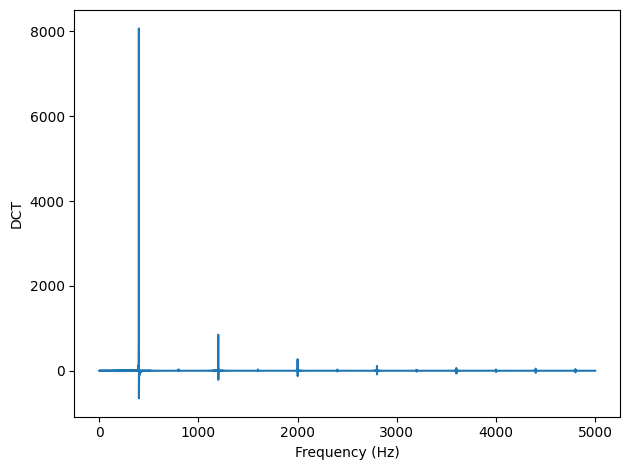

In [22]:
from thinkdsp import decorate

dct = wave.make_dct()
dct.plot()
decorate(xlabel='Frequency (Hz)', ylabel='DCT')

Dct provides `make_wave`, which performs the inverse DCT.

In [23]:
wave2 = dct.make_wave()

The result is very close to the wave we started with.

In [24]:
np.max(np.abs(wave.ys-wave2.ys))

np.float64(7.771561172376096e-16)

Negating the signal changes the sign of the DCT.

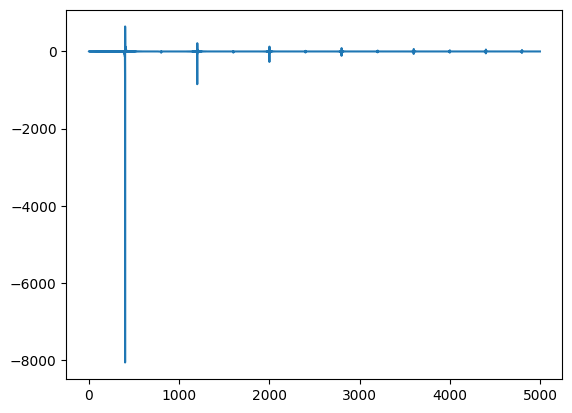

In [25]:
signal = TriangleSignal(freq=400, offset=0)
wave = signal.make_wave(duration=1.0, framerate=10000)
wave.ys *= -1
wave.make_dct().plot()

Adding phase offset $\phi=\pi$ has the same effect.

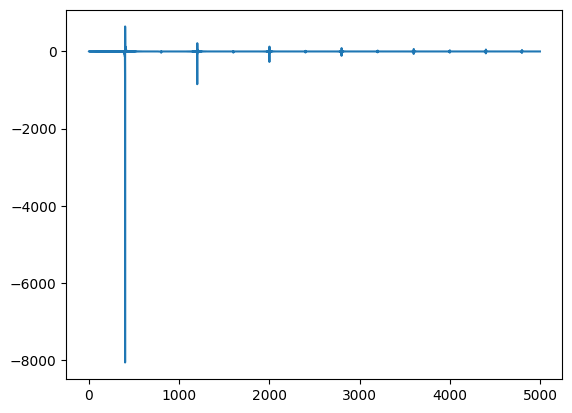

In [26]:
signal = TriangleSignal(freq=400, offset=np.pi)
wave = signal.make_wave(duration=1.0, framerate=10000)
wave.make_dct().plot()

#6.1 Timing

In [27]:
# #try timing analyze 1, analyze 2, ct_iv, scipy.ftpack.dct
# # where n is the numebr of samples?

# # so this doesn't actually work because

# import random

# input_sizes = np.logspace(0, 10)

# # want there to be size/framerate smaples

# for size in input_sizes:
#     amps = [random.random() for _ in range(int(size))]
#     ts = np.linspace(0, 1, int(size), endpoint=False)
#     fs = [random.randint(100,1000) for _ in range(int(size))]

#     ys = synthesize1(amps, fs, ts)
#     wave = Wave(ys, framerate)

#     print(len(fs))
#     print(len(ts))

#     %timeit analyze1(ys, fs, ts)


# first iea -> it doens't matter what wave/noise we pick just pick one with enough samples
# so that we can use a slice of those sampels as our input for figuring out the amplitue
# the whole idea is that you can tak e a list of ys wave amplitudes, take a list of times and frequencies an solve for the amplitue


In [28]:
# we can choose frequencies and times using DCT-IV makes eveyrhting easier

# powers of 2

# defines the samples sizes

# gives lsit of ns
# then we want a way to take that sample size and analyze it
# also jsut take a random noise to analyze so we have ys and then can slice it as long as
# the larest n value is still smaller

from thinkdsp import UncorrelatedGaussianNoise

signal = UncorrelatedGaussianNoise()
noise = signal.make_wave(duration=1.0, framerate=16384)
# and essnetially what we want to do is that we want a funtion takes in the N
# runs teh test stores it


In [29]:
def run_test(results, Ns, fn):
    for N in Ns:
        ts = (0.5 + np.arange(N)) / N
        fs = (0.5 + np.arange(N)) / 2
        result = %timeit -o fn(noise.ys[:N], fs, ts)
        results[N] = result.best
    return results

In [8]:
import matplotlib.pyplot as plt
from scipy.stats import linregress

# takes in the results dict which has the time and the sample siz e
def plot_results(results):
    # on a log log scale
    # x axis is defined as the
    # xaxis smaple size
    # y axis is teh time
    print(len(results.keys()))
    print(len(results.values()))
    plt.plot(results.keys(), results.values())
    plt.xscale('log')
    plt.yscale('log')
    plt.ylabel("Time")
    plt.xlabel("Number of Samples (n)")

    x = np.log(list(results.keys()))
    y = np.log(list(results.values()))
    t = linregress(x,y)
    slope = t[0]

    return slope



451 µs ± 184 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
693 µs ± 78.3 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
2.66 ms ± 118 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
20.1 ms ± 3.53 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
90.8 ms ± 16.4 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
449 ms ± 22.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
3.01 s ± 492 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
7
7
2.236941921557689


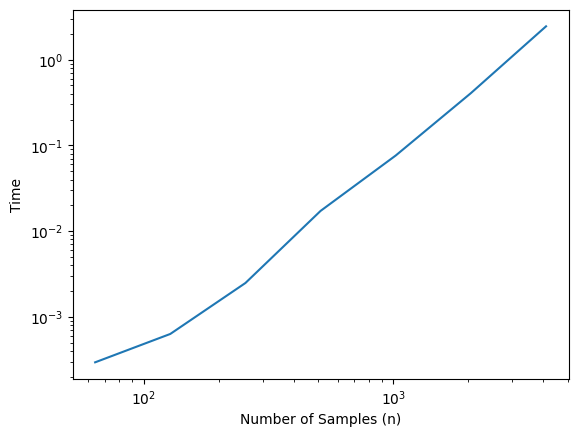

In [31]:
# actually run teh functions
n = 2 ** np.arange(6, 13)
results = run_test({}, n, analyze1)
slope = plot_results(results)
print(slope)



In [32]:
# try for analyze2, dct_iv, scipy.fftpack.dct
results = run_test({}, n, analyze2)
slope = plot_results(results)
print(slope)

129 µs ± 23.9 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


KeyboardInterrupt: 

In [ ]:
import scipy.fftpack

def scipy_dct(ys, freqs, ts):
    return scipy.fftpack.dct(ys,type=3)

results = run_test({}, n, scipy_dct)
slope = plot_results(results)
print(slope)

In [ ]:
def dct_iv_wrapper(ys, fs, ts):
    return dct_iv(ys)

results = run_test({}, n, dct_iv_wrapper)

slope = plot_results(results)
print(slope)

#6.2 Compression

In [52]:
def dct_for_compression(seg_size, wave):
    i, j = 0, seg_size
    segment_dct_map = {}

    while j < len(wave.ys):
        segment = wave.slice(i, j)
        dct = np.array(dct_iv(wave.ys[i:j]))
        segment_dct_map[(i+j)/2] = dct

        i += seg_size
        j += seg_size

    return segment_dct_map

    # can also just brorow the Spectrogram function which is exactly what this is takes a list of amplitudes and frequencies for each spectrum and a seg elgnth


In [53]:
from thinkdsp import read_wave, PI2, Wave
import numpy as np

wave = read_wave('/content/386984__epicwizard__serbia-political-rally-speech-2017.wav')
segment = wave.segment(start=2, duration=4)
segment.make_audio()

In [69]:
results = dct_for_compression(512, segment)
# we now have the dct - > amplitude lsit for each of our segments

# and now we need filter out
# and then we joint hem together? how does that work, synthesize?

new_map = {}


for segment2, ampList in results.items():
    newCopy = ampList.copy()
    newCopy[abs(newCopy) < 10] = 0
    new_map[segment2] = newCopy

# i guess you could make a lsit of lists and then convert it toa. sparse array adn then cinvert it back

def inverse_dct_iv(amps):
    return dct_iv(amps) * 2

new_ys = [sample for amp in new_map.values() for sample in inverse_dct_iv(amp)]

new_wave = Wave(new_ys, wave.ts, segment.framerate)
new_wave.make_audio()
# for each of the semgents now we have a list of amplitudes for each of the frequencies
#  inverse dct on the amplitues to get the ys
# how do you construct synthesie

# cna use make_dct over dct_iv and then you have a dct object




# visually inspecting it, how do i know what to make the cut off plot the freqeuencies and amplides



{256.0: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.

In [11]:
len(results)

93